## Lagrange orbits - Second order system with hard constrains

---



*   The original formulation of the problem yielded a periodic solution with period $T = 4$. To mitigate the effects of saturation in the $tanh$ activation function, the governing equations and initial conditions were rescaled so that the resulting period became $T = 0.5$. Consequently, the network inputs remained largely within the near-linear operating region of the activation function, facilitating more effective training of the PINN.

*   The applied scaling transformation preserves the governing equations and only changes the scales of the independent and dependent variables. Consequently, the rescaled problem is dynamically equivalent to the original system while being more suitable for neural network training.



In [14]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [15]:
!pip install deepxde

In [16]:
!pip install tensorflow tf_keras matplotlib numpy scipy

#Training


*   hardware - TPU  (or CPU if not available)
*   Important hyperparameters: loss_weights , learning rate
*   Two learning rates, $10^{-4}$ and $10^{-5}$, were investigated. The smaller learning rate resulted in improved fitting accuracy and lower training loss. However, inspection of the training and test loss curves indicates that, after approximately 70,000 epochs, further training does not improve the test loss. This behavior suggests the onset of overfitting, whereby the network continues to reduce the training error without achieving better generalization performance.







Set the default float type to float64
Compiling model...
'compile' took 0.004385 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [2.41e+01, 3.15e+00, 1.09e+01, 1.58e+01, 3.65e+00, 2.64e+01]    [2.44e+01, 2.29e+00, 9.21e+00, 1.69e+01, 4.07e+00, 2.59e+01]    []  
1000      [1.87e+01, 3.13e+00, 1.03e+01, 1.16e+01, 3.93e+00, 1.83e+01]    [1.84e+01, 2.24e+00, 8.63e+00, 1.19e+01, 4.06e+00, 1.71e+01]    []  
2000      [1.63e+01, 1.95e+00, 8.60e+00, 9.32e+00, 2.37e+00, 1.63e+01]    [1.51e+01, 1.29e+00, 7.19e+00, 8.86e+00, 2.24e+00, 1.44e+01]    []  
3000      [1.48e+01, 7.41e-01, 5.36e+00, 9.39e+00, 2.63e+00, 1.33e+01]    [1.33e+01, 3.64e-01, 4.49e+00, 8.55e+00, 2.36e+00, 1.16e+01]    []  
4000      [1.25e+01, 3.97e-01, 2.49e+00, 9.88e+00, 4.15e+00, 9.12e+00]    [1.17e+01, 1.68e-01, 2.17e+00, 9.22e+00, 3.80e+00, 8.36e+00]    []  
5000      [1.10e+01, 9.21e-01, 1

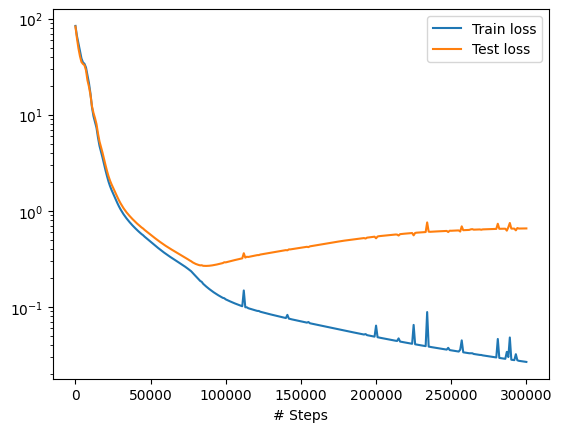

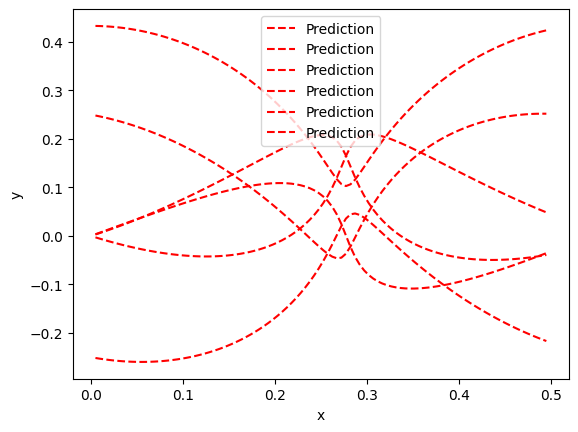

In [17]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

dde.config.set_default_float("float64")
seed=137
np.random.seed(seed)
tf.random.set_seed(seed)
dde.config.set_random_seed(seed)

# Constants
scale=2  #scale factor  -- time/scale**3 -- space/scale**2 -- velocities*scale
G = 1.0
m = [1.0, 1.0, 1.0]
endTime = 4/scale**3

num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [64]*3 + [6]  # 6 outputs for positions only
activation = "tanh"
initializer = "Glorot uniform"
loss_weights = [1]*4 +[1]*2
iterations = 300000
learning_rate = 1e-5
eps = 1e-9

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------
omega=0.3
# positions
x1_0, y1_0 = -1.0/scale**2, 0.0/scale**2
x2_0, y2_0 =  1.0/scale**2, 0.0/scale**2
x3_0, y3_0 =  0.0/scale**2, np.sqrt(3)/scale**2

# velocities
vx1_0, vy1_0 = (-np.sqrt(3)/3)*omega*scale, 1*omega*scale
vx2_0, vy2_0 = (-np.sqrt(3)/3)*omega*scale, -1*omega*scale
vx3_0, vy3_0 = (2*np.sqrt(3)/3)*omega*scale, 0*scale

y0 = np.array([x1_0, y1_0, x2_0, y2_0,x3_0, y3_0], dtype=np.float64)
v0 = np.array([vx1_0, vy1_0, vx2_0, vy2_0,vx3_0, vy3_0], dtype=np.float64)

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)


# ============================================================
# Residual for second-order ODEs
# ============================================================
def three_body_ode_second(t, y):
    # r: [batch_size, 6] -> x1,y1,x2,y2,x3,y3
    x1, y1, x2, y2, x3, y3 = [y[:, i:i+1] for i in range(6)]

    # pairwise distances
    r12 = tf.sqrt((x1 - x2)**2 + (y1 - y2)**2 )
    r13 = tf.sqrt((x1 - x3)**2 + (y1 - y3)**2 )
    r23 = tf.sqrt((x2 - x3)**2 + (y2 - y3)**2 )

    r12_3 = (r12+eps)**3
    r13_3 = (r13+eps)**3
    r23_3 = (r23+eps)**3

    # accelerations
    ax1 = G*( m[1]*(x2 - x1)/r12_3 + m[2]*(x3 - x1)/r13_3 )
    ay1 = G*( m[1]*(y2 - y1)/r12_3 + m[2]*(y3 - y1)/r13_3 )
    ax2 = G*( m[0]*(x1 - x2)/r12_3 + m[2]*(x3 - x2)/r23_3 )
    ay2 = G*( m[0]*(y1 - y2)/r12_3 + m[2]*(y3 - y2)/r23_3 )
    ax3 = G*( m[0]*(x1 - x3)/r13_3 + m[1]*(x2 - x3)/r23_3 )
    ay3 = G*( m[0]*(y1 - y3)/r13_3 + m[1]*(y2 - y3)/r23_3 )

    # second derivatives
    x1_tt = dde.grad.hessian(y, t, component=0, i=0, j=0)
    y1_tt = dde.grad.hessian(y, t, component=1, i=0, j=0)
    x2_tt = dde.grad.hessian(y, t, component=2, i=0, j=0)
    y2_tt = dde.grad.hessian(y, t, component=3, i=0, j=0)
    x3_tt = dde.grad.hessian(y, t, component=4, i=0, j=0)
    y3_tt = dde.grad.hessian(y, t, component=5, i=0, j=0)

    return [
        x1_tt - ax1,
        y1_tt - ay1,
        x2_tt - ax2,
        y2_tt - ay2,
        x3_tt - ax3,
        y3_tt - ay3
    ]

# --------------------------------------------------
# Geometry
# --------------------------------------------------
geom = dde.geometry.TimeDomain(0, endTime)


data = dde.data.PDE(
    geom,
    three_body_ode_second,
    [],
    num_domain=num_domain,
    num_boundary=num_boundary,
    num_test=num_test
)

# ============================================================
# Network and hard constraints
# ============================================================
net = dde.nn.FNN(layer_size, activation, initializer)

# --------------------------------------------------
# HARD CONSTRAINTS (position + velocity)
# --------------------------------------------------
def output_transform(t, y):
    """
    Enforces:
    y(0) = y0
    y'(0) = v0
    """
    return y0_tf + v0_tf * t + (t**2) * y

net.apply_output_transform(output_transform)

model = dde.Model(data, net)


#model.compile(
#    optimizer=tf.keras.optimizers.AdamW(1e-4, weight_decay=1e-5,loss_weights=loss_weights),
#    loss="MSE",
#)
model.compile("adam", lr=learning_rate, loss_weights=loss_weights, loss="MSE")
losshistory, train_state = model.train(iterations=iterations)

#model.compile("L-BFGS")  # no learning rate needed
#losshistory, train_state = model.train()

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

#Plots and Results

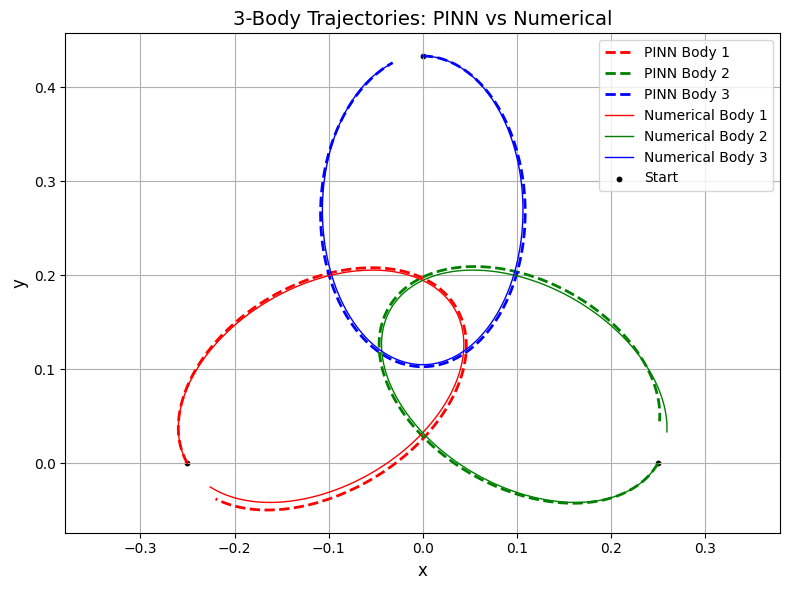


--- L2 Relative Errors ---
Body 1 x error: 3.45e-02
Body 1 y error: 5.62e-02
Body 2 x error: 3.50e-02
Body 2 y error: 6.97e-02
Body 3 x error: 4.34e-02
Body 3 y error: 1.49e-02
(301, 6)


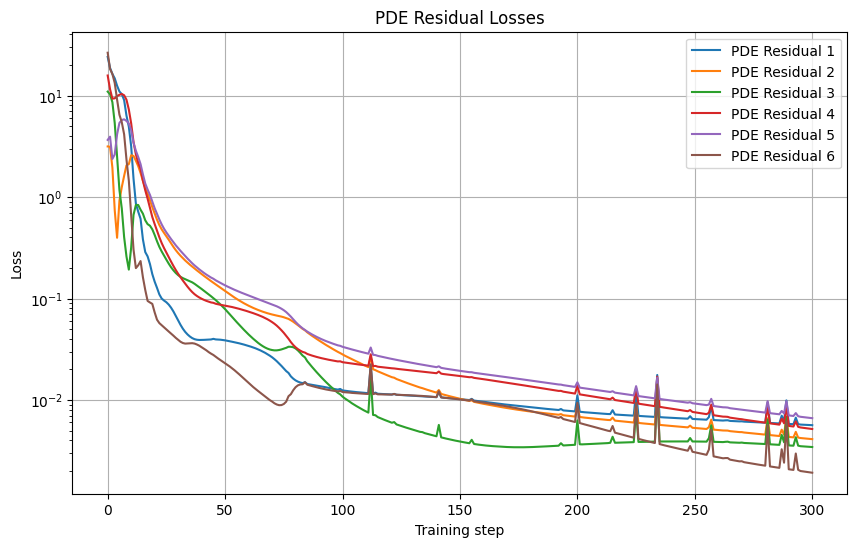

In [18]:
# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================
def three_body_numeric(t, y, G=1.0, m=(1.0, 1.0, 1.0)):
    x1, y1, vx1, vy1, x2, y2, vx2, vy2, x3, y3, vx3, vy3 = y

    r12 = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 )+eps
    r13 = np.sqrt((x1 - x3)**2 + (y1 - y3)**2 )+eps
    r23 = np.sqrt((x2 - x3)**2 + (y2 - y3)**2 )+eps

    ax1 = G * (m[1]*(x2 - x1)/r12**3 + m[2]*(x3 - x1)/r13**3)
    ay1 = G * (m[1]*(y2 - y1)/r12**3 + m[2]*(y3 - y1)/r13**3)
    ax2 = G * (m[0]*(x1 - x2)/r12**3 + m[2]*(x3 - x2)/r23**3)
    ay2 = G * (m[0]*(y1 - y2)/r12**3 + m[2]*(y3 - y2)/r23**3)
    ax3 = G * (m[0]*(x1 - x3)/r13**3 + m[1]*(x2 - x3)/r23**3)
    ay3 = G * (m[0]*(y1 - y3)/r13**3 + m[1]*(y2 - y3)/r23**3)

    return [vx1, vy1, ax1, ay1,
            vx2, vy2, ax2, ay2,
            vx3, vy3, ax3, ay3]

t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")



#============================ history losses per pfe res =================================
losses = np.array(losshistory.loss_train)
print(losses.shape)

#dde.utils.plot_loss_history(losshistory)


pde_losses = losses[:, 1:13]

plt.figure(figsize=(10, 6))

for i in range(6):
    plt.semilogy(losses[:, i], label=f"PDE Residual {i+1}")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("PDE Residual Losses")
plt.legend()
plt.grid(True)
plt.show()

#Extrapolation for two Periods

======================= Extrapolating for 2 Periods ===============================


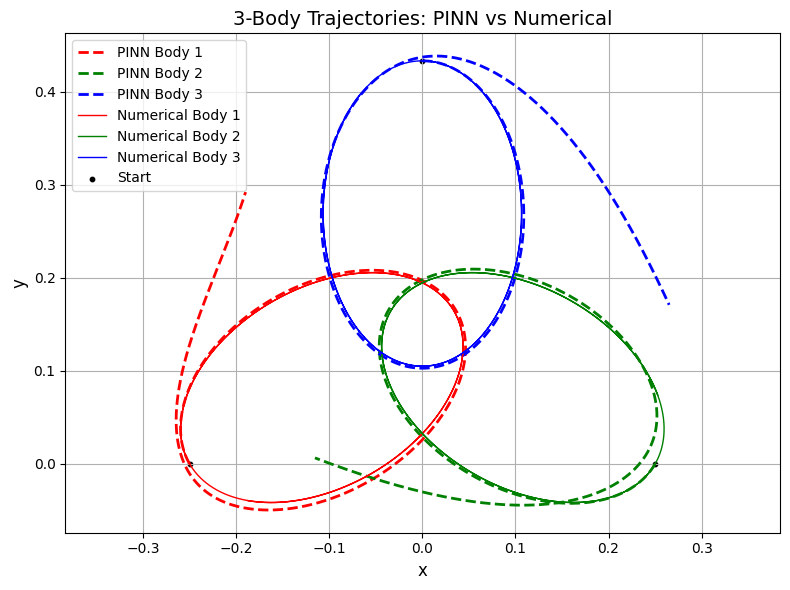


--- L2 Relative Errors ---
Body 1 x error: 4.58e-01
Body 1 y error: 1.05e+00
Body 2 x error: 5.69e-01
Body 2 y error: 8.03e-01
Body 3 x error: 1.74e+00
Body 3 y error: 2.13e-01


In [19]:
#============================ EXTRAPOLATE =================================================
print("===================================================================================")
print("======================= Extrapolating for 2 Periods ===============================")
print("===================================================================================")

endTime=2*endTime

# ============================================================
# PINN Predictions
# ============================================================
t_test = np.linspace(0, endTime, 5000)[:, None]
y_pred = model.predict(t_test)

x1, y1 = y_pred[:, 0], y_pred[:, 1]
x2, y2 = y_pred[:, 2], y_pred[:, 3]
x3, y3 = y_pred[:, 4], y_pred[:, 5]

# ============================================================
# Numerical Solution via SciPy
# ============================================================


t_span = (0, endTime)
t_eval = np.linspace(0, endTime, 5000)

y0_full = np.array([
    x1_0, y1_0, vx1_0, vy1_0,
    x2_0, y2_0, vx2_0, vy2_0,
    x3_0, y3_0, vx3_0, vy3_0
])

sol = solve_ivp(three_body_numeric, t_span, y0_full, t_eval=t_eval, rtol=1e-10, atol=1e-12)

x1_n, y1_n = sol.y[0], sol.y[1]
x2_n, y2_n = sol.y[4], sol.y[5]
x3_n, y3_n = sol.y[8], sol.y[9]

# ============================================================
# Compare and Plot Results
# ============================================================
plt.figure(figsize=(8, 6))
plt.plot(x1, y1, 'r--', lw=2, label="PINN Body 1")
plt.plot(x2, y2, 'g--', lw=2, label="PINN Body 2")
plt.plot(x3, y3, 'b--', lw=2, label="PINN Body 3")

plt.plot(x1_n, y1_n, 'r-', lw=1, label="Numerical Body 1")
plt.plot(x2_n, y2_n, 'g-', lw=1, label="Numerical Body 2")
plt.plot(x3_n, y3_n, 'b-', lw=1, label="Numerical Body 3")

plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=10, label='Start')

plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.title("3-Body Trajectories: PINN vs Numerical", fontsize=14)
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")